# Miltimodal SAR sea ice segmentation 

This notebook trains and evaluates a multimodal semantic segmentation model using:

- **THOR ViT Base** for Sentinel-1 SAR channels: HH and HV
- **DINO ViT Small** for the Doppler proxy channel
- **FCNDecoder** for two-class semantic segmentation

Target labels:

- `-1` = ignored area / land
- `0` = ice
- `1` = water

## 1. Imports and runtime setup

In [22]:
from pathlib import Path
import albumentations as A
import torch
from albumentations.pytorch import ToTensorV2
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from lightning.pytorch.loggers import TensorBoardLogger

import thor_terratorch_ext
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.tasks import SemanticSegmentationTask


torch.set_float32_matmul_precision("medium")


print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.12.1+cu130
CUDA available: True


## 2. Project and dataset configuration 

Set 'DATA_ROOT' to the directory containing:

```text
DATA_ROOT/
    tif_images/
    tif_doppler/
    tif_mask/
    splits/
        train.txt
        val.txt
        test.txt

In [ ]:
# update this path to the dataset directory
DATA_ROOT = Path("").expanduser().resolve()


S1_IMAGES = DATA_ROOT / "tif_images"
DOPPLER_IMAGES = DATA_ROOT / "tif_doppler"
MASKS_DIR = DATA_ROOT / "tif_mask"
SPLITS_DIR = DATA_ROOT / "splits"


# find the repository root 
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path
        for path in [CURRENT_DIR, *CURRENT_DIR.parents]
        if (path / "pyproject.toml").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "could not find the repository root with pyproject.toml"
    )


EXPERIMENT = "thor_s1_doppler"

RESULTS_ROOT = PROJECT_ROOT / "results"
DEFAULT_ROOT_DIR = RESULTS_ROOT / EXPERIMENT

DEFAULT_ROOT_DIR.mkdir(parents=True, exist_ok=True)


MAX_EPOCHS = 200
BATCH_SIZE = 4
NUM_WORKERS = 0

S1_BANDS = ["EW_HH", "EW_HV"]

DOPPLER_BANDS = ["DOPPLER"]

S1_MEANS = [139.9802950682014, 114.3046808294434]
S1_STDS = [52.433221109613626, 60.61472859030126]

DOPPLER_MEANS = [0.46692912768293554]
DOPPLER_STDS = [0.2555213128223904]


required_paths = {
    "Sentinel-1 images": S1_IMAGES,
    "Doppler images": DOPPLER_IMAGES,
    "masks": MASKS_DIR,
    "splits": SPLITS_DIR,
}


for name, path in required_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing dataset path: {name}: {path}"
        )


print("Data root:", DATA_ROOT)
print("Project root:", PROJECT_ROOT)
print("Results directory:", DEFAULT_ROOT_DIR)

## 3. Data module

In [ ]:
datamodule = GenericMultiModalDataModule(
    task="segmentation",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    modalities=["S1", "DOPPLER"],
    rgb_modality="S1",
    rgb_indices=[0, 1, 1],
    train_data_root={
        "S1": str(S1_IMAGES),
        "DOPPLER": str(DOPPLER_IMAGES),
    },
    train_label_data_root=str(MASKS_DIR),
    val_data_root={
        "S1": str(S1_IMAGES),
        "DOPPLER": str(DOPPLER_IMAGES),
    },
    val_label_data_root=str(MASKS_DIR),
    test_data_root={
        "S1": str(S1_IMAGES),
        "DOPPLER": str(DOPPLER_IMAGES),
    },
    test_label_data_root=str(MASKS_DIR),
    train_split=str(SPLITS_DIR / "train.txt"),
    val_split=str(SPLITS_DIR / "val.txt"),
    test_split=str(SPLITS_DIR / "test.txt"),
    allow_substring_file_names=True,
    image_grep={
        "S1": "*.tif",
        "DOPPLER": "*_doppler.tif",
    },
    label_grep="*_mask.tif",
    no_label_replace=-1,
    no_data_replace=0,
    concat_bands=True,
    check_stackability=False,
    dataset_bands={
        "S1": S1_BANDS,
        "DOPPLER": DOPPLER_BANDS,
    },
    means={
        "S1": S1_MEANS,
        "DOPPLER": DOPPLER_MEANS,
    },
    stds={
        "S1": S1_STDS,
        "DOPPLER": DOPPLER_STDS,
    },
    num_classes=2,
    train_transform=[
        A.RandomCrop(
            height=288,
            width=288,
        ),
        A.D4(),
        ToTensorV2(),
    ],
)

datamodule.setup("fit")

print("Train batches:", len(datamodule.train_dataloader()))
print("Validation batches:", len(datamodule.val_dataloader()))

## 4. Multimodal model configuration

In [26]:
model_args = {
    "backbone": "MultiBackboneWrapper",
    "backbone_bands": [
        "EW_HH",
        "EW_HV",
        "DOPPLER",
    ],
    "backbone_merge_features": "concat",
    "backbone_rescale_features": "up",
    "backbone_encoders": [
        {
            "thor_v1_base": {
                "freeze_backbone": True,
                "backbone_merge_method": "concat",
                "backbone_pretrained": True,
                "backbone_input_params": {
                    "ground_covers": [2880],
                    "flexivit_patch_size_seqs": [8],
                },
                "backbone_out_indices": [-1],
                "backbone_model_bands": [
                    "EW_HH",
                    "EW_HV",
                ],
            }
        },
        {
            "vit_small_patch16_224.dino": {
                "out_indices": [-1],
                "in_chans": 1,
                "backbone_pretrained": True,
                "backbone_dynamic_img_size": True,
                "bands": ["DOPPLER"],
            }
        },
    ],
    "decoder": "FCNDecoder",
    "decoder_channels": 256,
    "num_classes": 2,
    "head_dropout": 0.1,
}

sample_batch = next(iter(datamodule.train_dataloader()))

print("Input image shape:", sample_batch["image"].shape)
print(
    "THOR patch size:",
    model_args["backbone_encoders"][0]
    ["thor_v1_base"]
    ["backbone_input_params"]
    ["flexivit_patch_size_seqs"],
)


Input image shape: torch.Size([4, 3, 288, 288])
THOR patch size: [8]


## 5.Segmentation task

In [ ]:
task = SemanticSegmentationTask(
    model_args=model_args,
    model_factory="EncoderDecoderFactory",
    loss="ce",
    lr=2e-5,
    ignore_index=-1,
    optimizer="AdamW",
    optimizer_hparams={
        "weight_decay": 0.05,
    },
    scheduler="ReduceLROnPlateau",
    scheduler_hparams={
        "mode": "max",
        "factor": 0.5,
        "patience": 10,
        "threshold": 1e-4,
    },
    tiled_inference_on_validation=True,
    tiled_inference_on_testing=True,
    tiled_inference_parameters={
        "h_crop": 288,
        "h_stride": 256,
        "w_crop": 288,
        "w_stride": 256,
        "average_patches": True,
        "batch_size": 4,
    },
    freeze_backbone=False,
    freeze_decoder=False,
)

## 6. Trainer, logging, and callbacks

In [28]:
logger = TensorBoardLogger(
    save_dir=str(RESULTS_ROOT),
    name=EXPERIMENT,
)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(DEFAULT_ROOT_DIR / "checkpoints"),
    monitor="val/mIoU",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename="epoch{epoch:03d}",
    auto_insert_metric_name=False,
)

early_stopping = EarlyStopping(
    monitor="val/mIoU",
    mode="max",
    patience=30,
    min_delta=1e-4,
    check_finite=False,
    verbose=True,
)

trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    strategy="auto",
    devices="auto",
    num_nodes=1,
    precision="16-mixed" if torch.cuda.is_available() else "32-true",
    max_epochs=MAX_EPOCHS,
    check_val_every_n_epoch=1,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    enable_checkpointing=True,
    default_root_dir=str(DEFAULT_ROOT_DIR),
    logger=logger,
    callbacks=[
        checkpoint_callback,
        LearningRateMonitor(logging_interval="epoch"),
        early_stopping,
    ],
    enable_progress_bar=True,
    enable_model_summary=True,
)

trainer


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## 7. Training

In [ ]:
trainer.fit(
    model=task,
    datamodule=datamodule,
)

print("best checkpoint:", checkpoint_callback.best_model_path)

## 8. Test evaluation

The best checkpoint selected by validation mIoU

In [ ]:
test_metrics = trainer.test(
    model=task,
    datamodule=datamodule,
    ckpt_path="best",
)

test_metrics

INFO:terratorch:Test dataset: 32
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /home/predm/venvs/sar_sea_ice_classification/results/thor_s1_doppler/checkpoints/epoch104.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /home/predm/venvs/sar_sea_ice_classification/results/thor_s1_doppler/checkpoints/epoch104.ckpt


Output()

/home/predm/venvs/sar_sea_ice_classification/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/predm/venvs/sar_sea_ice_classification/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.9357608556747437     │
│    test/Boundary_mIoU     │   0.031489551067352295    │
│   test/Class_Accuracy_0   │    0.9687439203262329     │
│   test/Class_Accuracy_1   │    0.9027777910232544     │
│       test/F1_Score       │    0.9350608587265015     │
│        test/IoU_0         │    0.8795837759971619     │
│        test/IoU_1         │    0.8765016794204712     │
│    test/Pixel_Accuracy    │    0.9350724816322327     │
│         test/loss         │    0.16644823551177979    │
│         test/mIoU         │    0.8780426979064941     │
│      test/mIoU_Micro      │    0.8780621290206909     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.16644823551177979,
  'test/Accuracy': 0.9357608556747437,
  'test/Boundary_mIoU': 0.031489551067352295,
  'test/Class_Accuracy_0': 0.9687439203262329,
  'test/Class_Accuracy_1': 0.9027777910232544,
  'test/F1_Score': 0.9350608587265015,
  'test/IoU_0': 0.8795837759971619,
  'test/IoU_1': 0.8765016794204712,
  'test/Pixel_Accuracy': 0.9350724816322327,
  'test/mIoU': 0.8780426979064941,
  'test/mIoU_Micro': 0.8780621290206909}]

## 9. Load the best checkpoint for manual inference

The checkpoint is reloaded here because the following cells perform manual inference and visualization outside the Lightning testing loop.

In [ ]:
best_ckpt = checkpoint_callback.best_model_path

checkpoint = torch.load(
    best_ckpt,
    map_location="cpu",
    weights_only=False,
)

task.load_state_dict(
    checkpoint["state_dict"],
    strict=True,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

task.to(device)
task.eval()

print("loaded best checkpoint:", best_ckpt)
print("inference device:", device)

## 10. Tiled inference on a test batch

In [ ]:
datamodule.setup("test")

test_dataset = datamodule.test_dataset
test_loader = datamodule.test_dataloader()

BATCH_INDEX = 1

selected_batch = None

for index, test_batch in enumerate(test_loader):
    if index == BATCH_INDEX:
        selected_batch = test_batch
        break

if selected_batch is None:
    raise IndexError(
        f"Test loader has fewer than {BATCH_INDEX + 1} batches."
    )

selected_batch = datamodule.aug(selected_batch)

images = selected_batch["image"].to(device)
masks = selected_batch["mask"].cpu().numpy()

with torch.no_grad():
    outputs = task.handle_full_or_tiled_inference(
        images,
        use_tiled_inference=True,
    )

predictions = (
    torch.argmax(outputs.output, dim=1)
    .cpu()
    .numpy()
)

print("predictions shape:", predictions.shape)


INFO:terratorch:Test dataset: 32


Predictions shape: (4, 1338, 1296)


## 11. Visualize predictions

The model predicts only classes `0` and `1`. Ignored pixels are masked with `-1` only for visualization that no-label regions do not appear as model predictions.

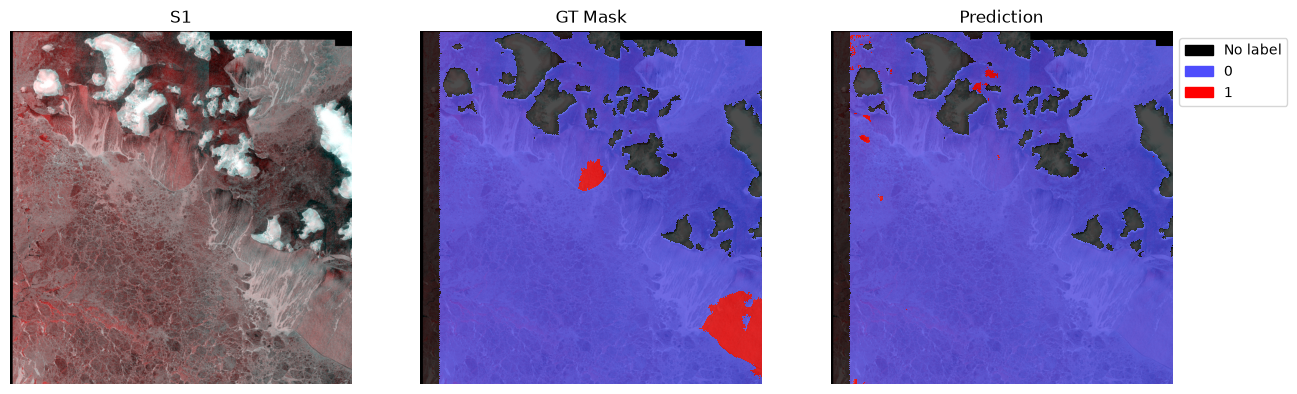

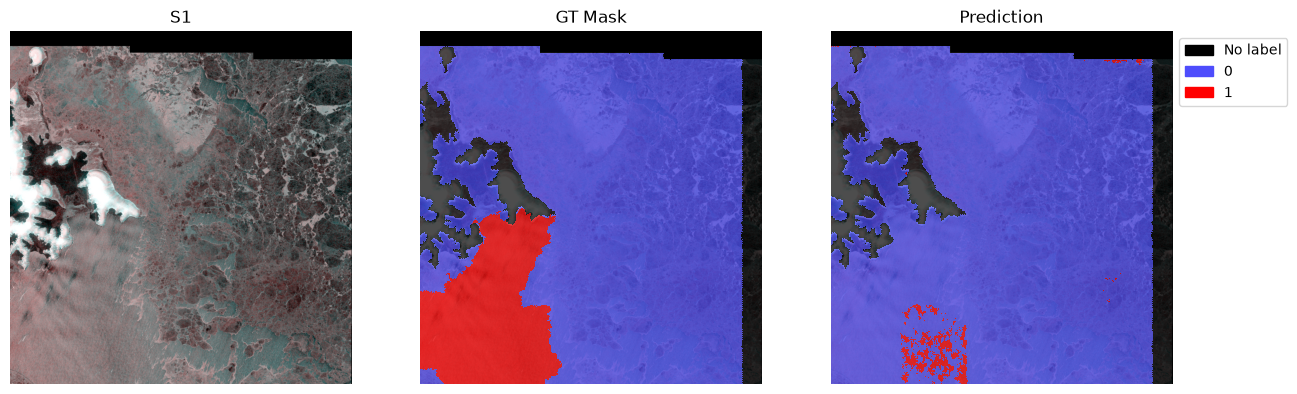

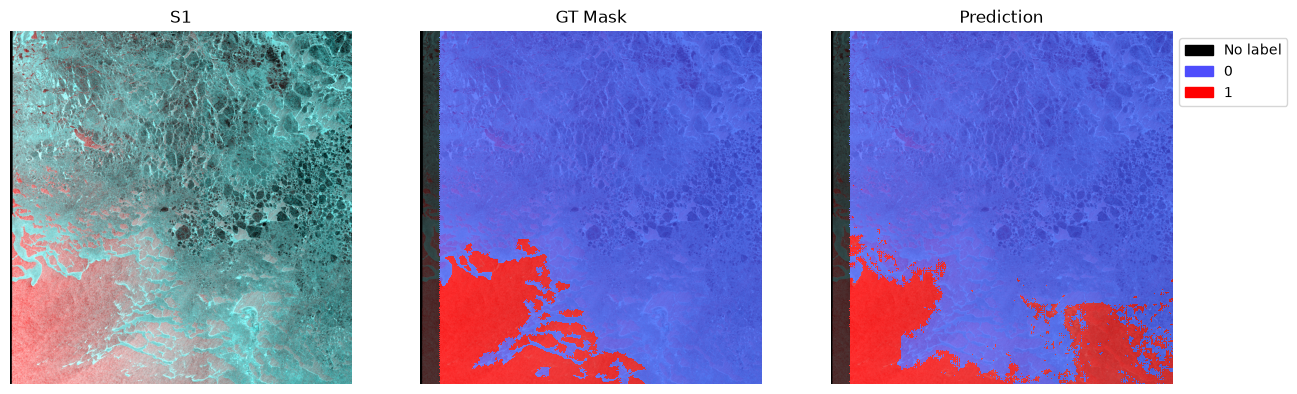

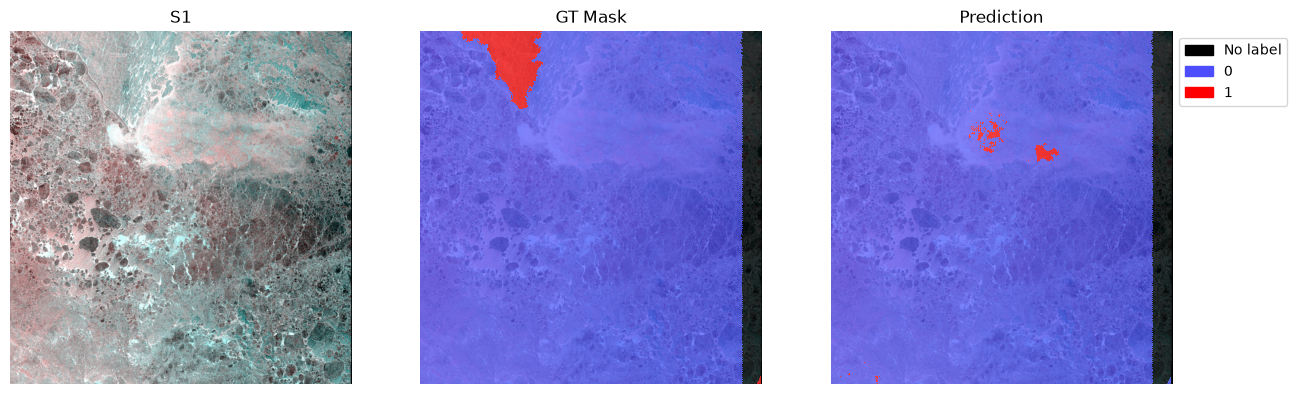

In [15]:
num_examples = min(6, len(predictions))

for i in range(num_examples):
    prediction_for_plot = predictions[i].copy()
    ground_truth = masks[i]

    # hide ignored pixels only for visualization
    prediction_for_plot[ground_truth == -1] = -1

    sample = {
        "S1": selected_batch["image"][i][:2].cpu(),
        "mask": selected_batch["mask"][i],
        "prediction": prediction_for_plot,
    }

    test_dataset.plot(sample)
